<a href="https://colab.research.google.com/github/eyramg/A01-data-wrangling/blob/main/notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Eyram Golo

**Date:** 09/10/2026

Q1

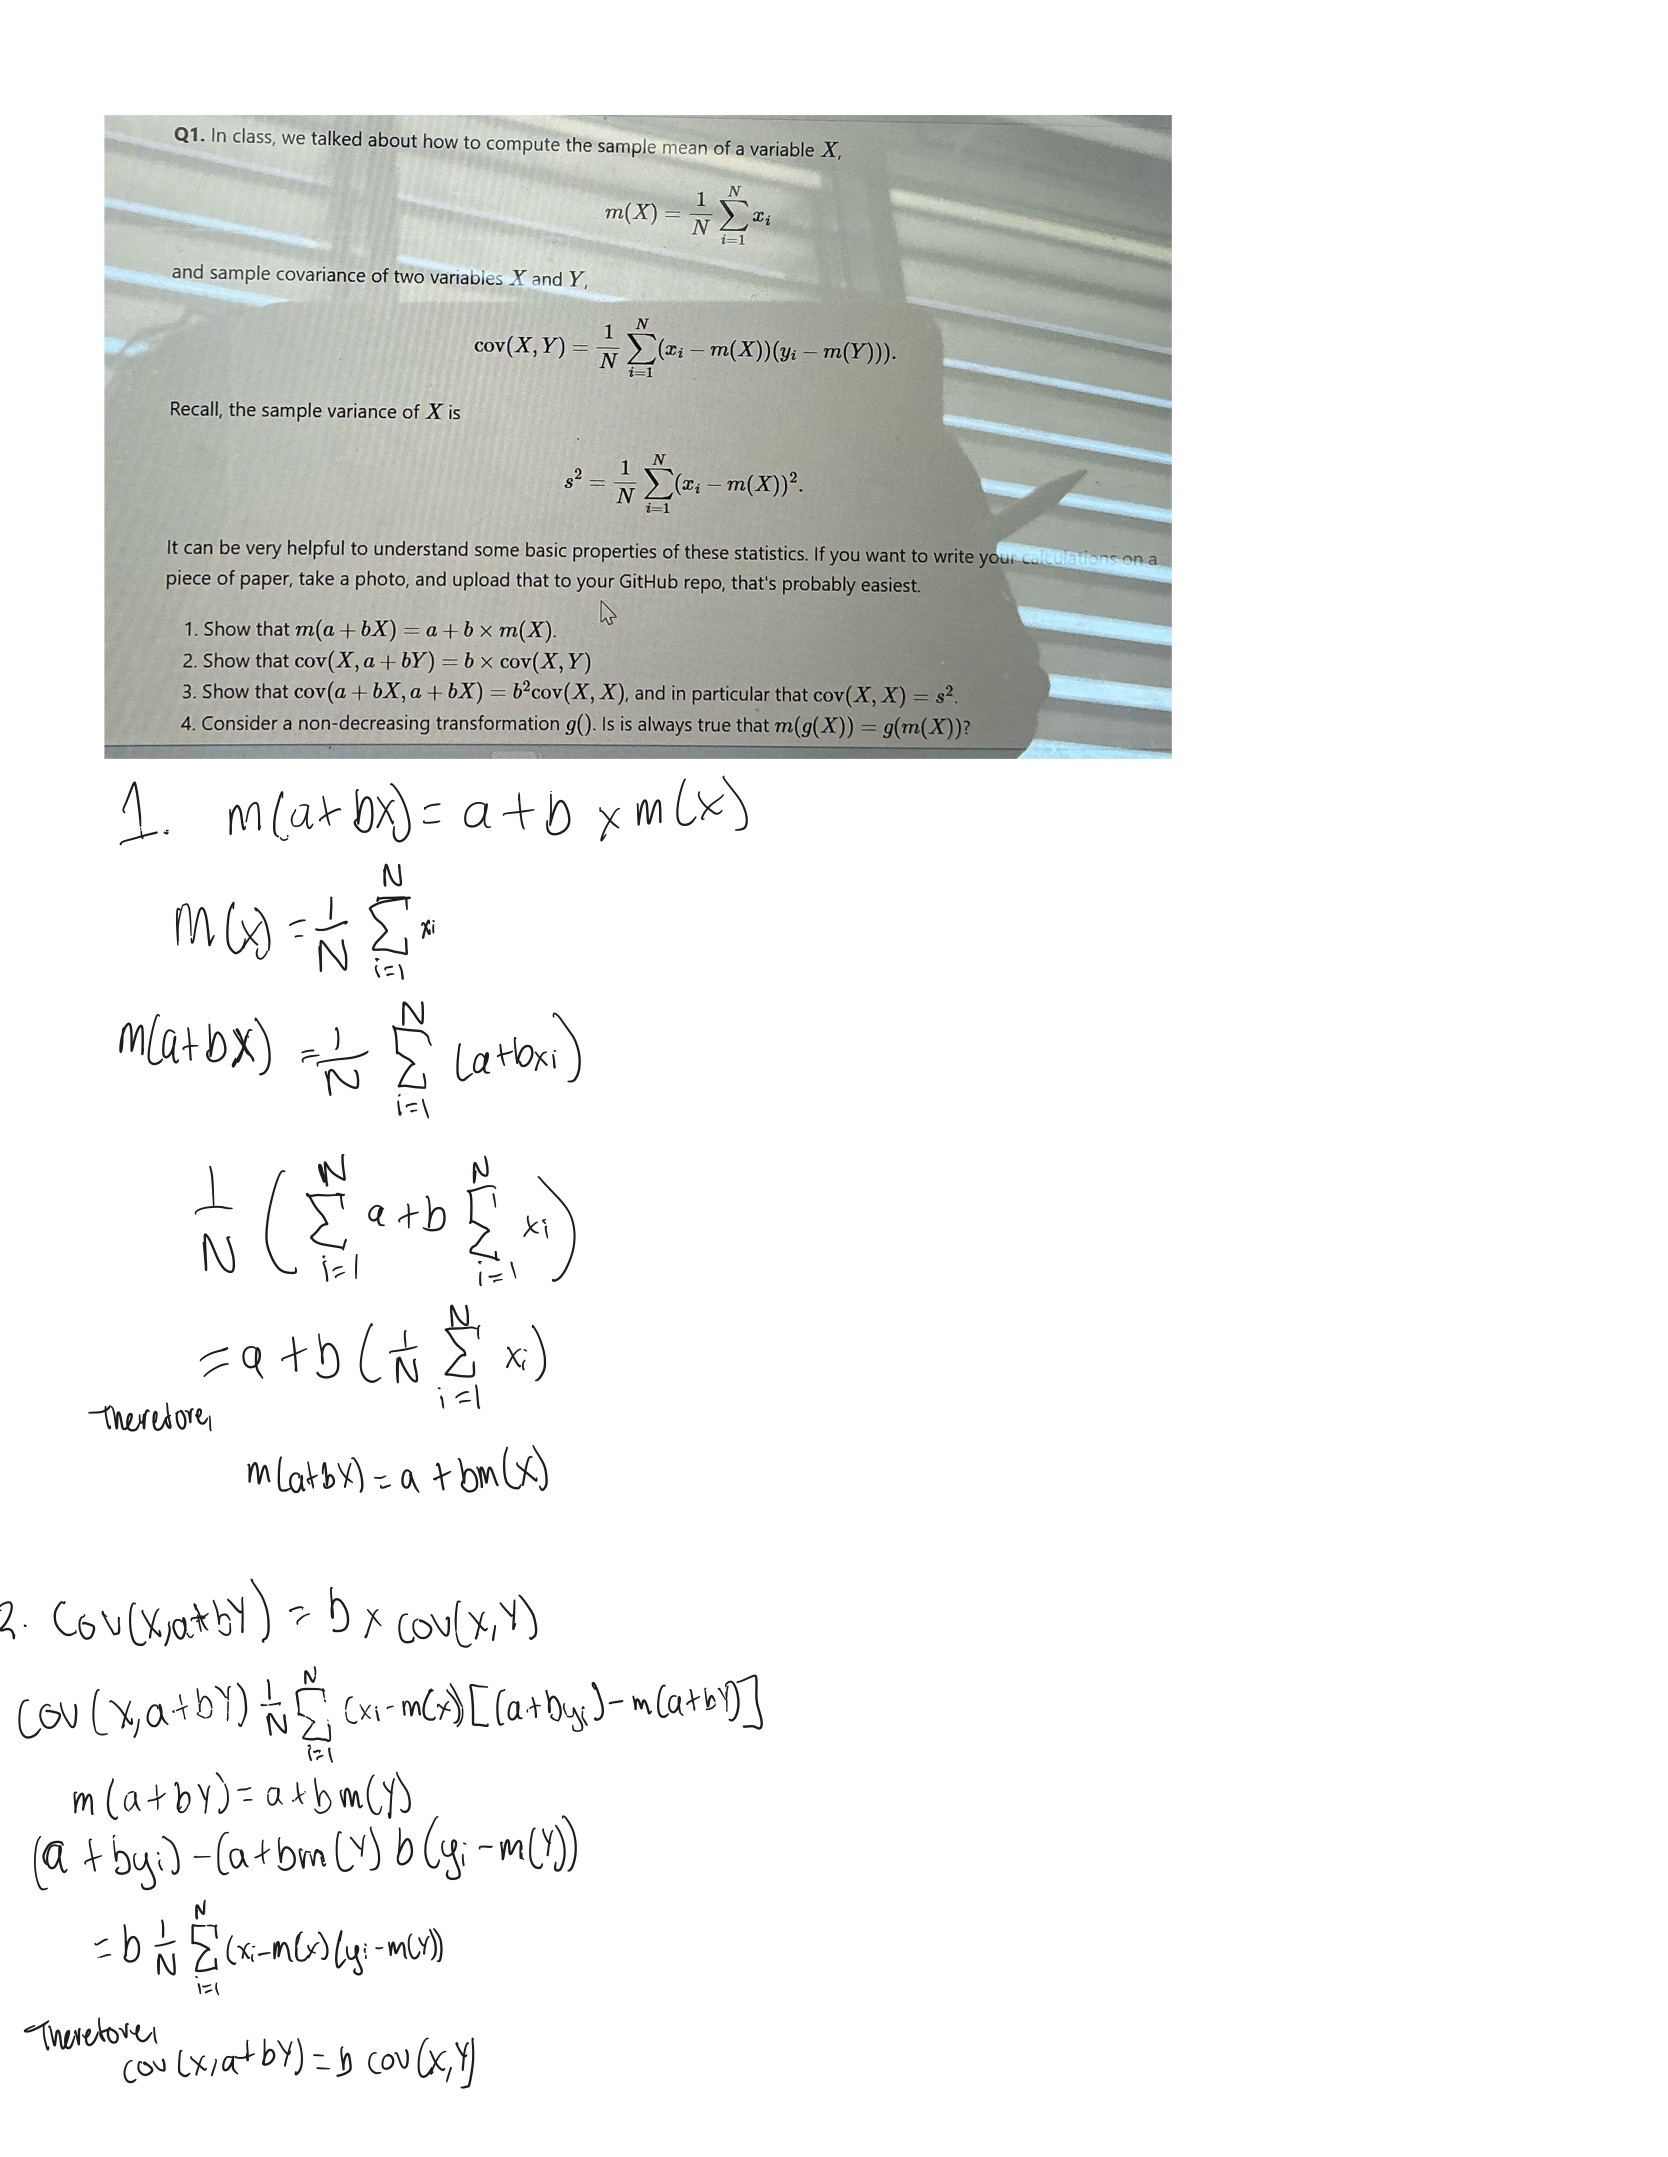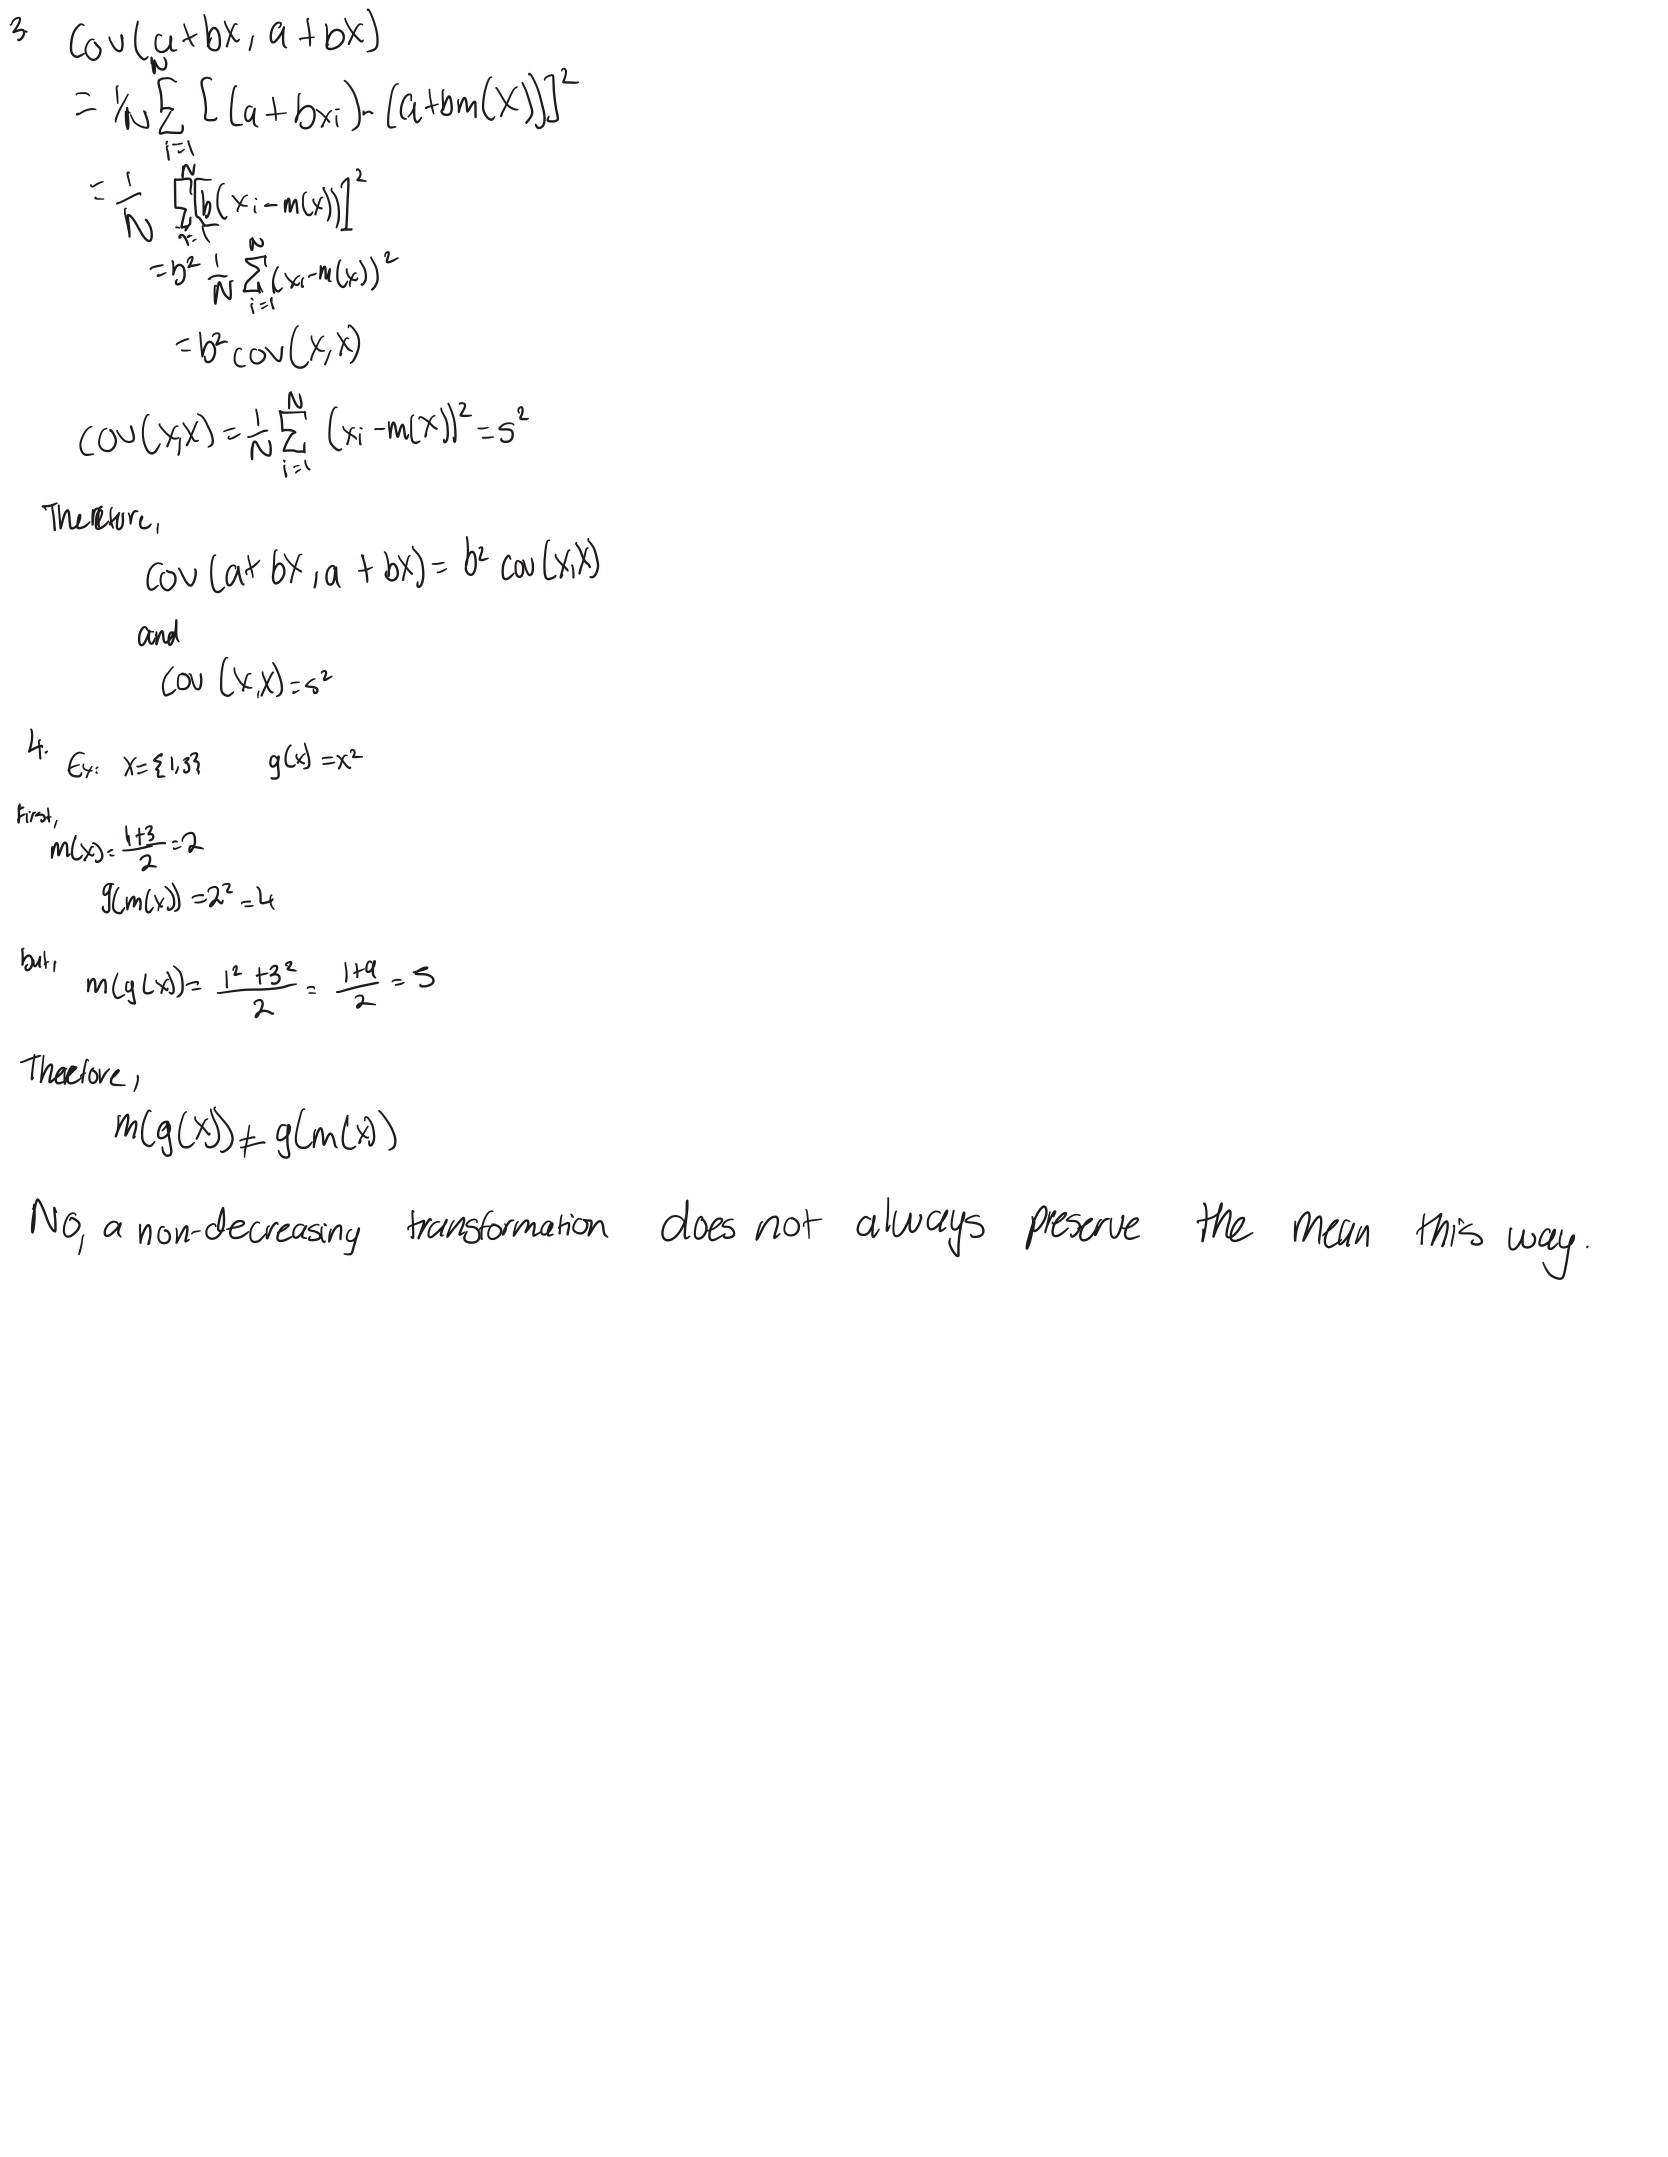

In [ ]:
Q2 , #2


In [6]:
import pandas as pd

df = pd.read_csv("ForeignGifts_edu.csv")

<Axes: >

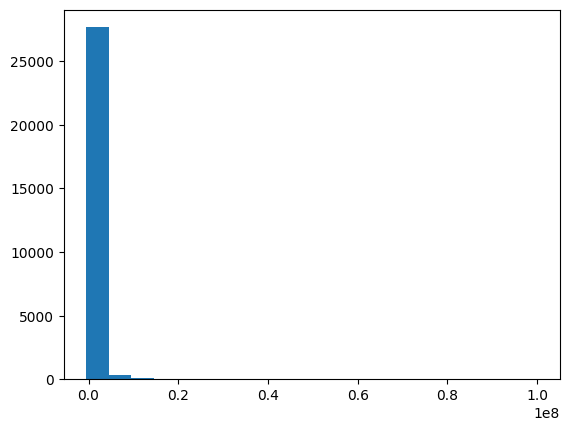

In [7]:
df['Foreign Gift Amount'].hist(bins=20, grid=False)

In [8]:
df['Foreign Gift Amount'].describe()

,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


Q2,2

The foreign Gift Amount variable appears mostly right-skewed. A small number of very large gifts create a long right tail, while most of the gifts are on the lower end. The median gift amount was around $94615, while the mean is about $588,233 which is way higher. The largest gift was $100 million and the lowest was -$537,700.

Q2.#3

In [9]:
df['Gift Type'].value_counts()

,count
Gift Type,
Contract,17274
Monetary Gift,10936
Real Estate,11


In [10]:
df['Gift Type'].value_counts(normalize=True)

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


Q2.3
Contracts make up the largest proportion of foreign gifts about 61.21% , next was the monetary gifts at about 38.75%. Real estate gifts were the most rare making about 0.04% of the gifts.

In [12]:
df['log_gift'] = np.nan

df.loc[df['Foreign Gift Amount'] > 0, 'log_gift'] = np.log(
    df.loc[df['Foreign Gift Amount'] > 0, 'Foreign Gift Amount']
)

<Axes: ylabel='Density'>

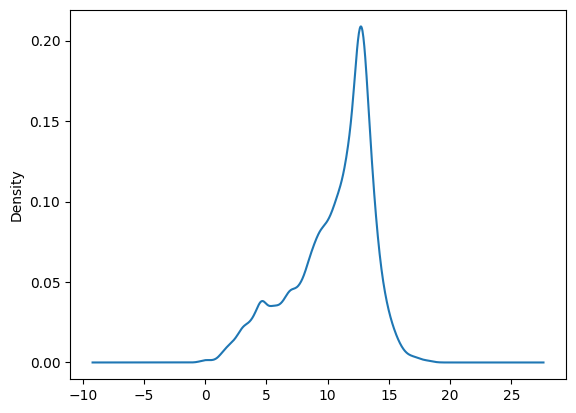

In [13]:
df['log_gift'].plot.density()

,log_gift
Gift Type,
Contract,"Axes(0.125,0.11;0.775x0.77)"
Monetary Gift,"Axes(0.125,0.11;0.775x0.77)"
Real Estate,"Axes(0.125,0.11;0.775x0.77)"


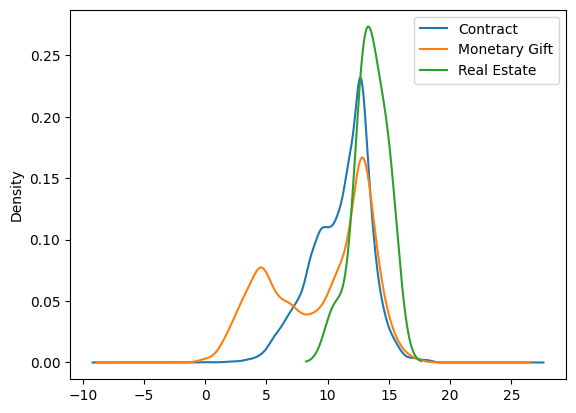

In [14]:
df.groupby('Gift Type')['log_gift'].plot.density(legend=True)

Q2, 4
After taking the log of Foreign Gift Amount, the distribution is less skewed. When comparing the gift types, contracts are mostly concentrated at higher gift amounts, while monetary gifts are more spread out and include more smaller amounts. Real estate gifts also appear to be concentrated at higher amounts, but there are only 11 real estate gifts, so this pattern should be interpreted sparingly.

In [15]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False).head(15)

,Foreign Gift Amount
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [16]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


England had the highest number of gifts with 3,655, next is China with 2,461 and Canada with 2,344. However, Qatar gave the largest total amount with about $2.72 billion. Following qatar is England at $1.46 billion and china at $1.24 billion.

Q2 , #6

In [17]:
df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


Q2, 6
With approximately $1.17 billion, Qatar Foundation providedteh most money in total. It was followed by Qatar National Res at approximately $796 million and Qatar Foundation for Education at approximately $374 million. Overall, Qatar-related organizations appear several times among the largest giftors.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** d2ddd55
- **AI tool and model used:** Ghatgpt 5.6

### *Prompts used

1. I completed Phase 1 of my DS 3001 Exploratory Data Analysis assignment on my own. Please review my answers and code for the Foreign Gifts question. Check whether my code correctly answers each question, whether my interpretations match the results, and whether there are any errors or areas that could be improved. Please explain your recommendations without making the work unnecessarily complicated.
2. Based on your review, what specific changes should I make to improve my analysis? Please focus on any issues with my visualizations, treatment of the Foreign Gift Amount variable, interpretation of the gift types, and the groupby calculations for countries and giftors. Keep the recommendations appropriate for a beginner DS 3001 student and explain why each change would improve my work.

### *AI-proposed changes


AI Proposed Changes

1. Clearly note that Foreign Gift Amount is strongly right-skewed because a small number of very large gifts pull the mean above the median.
2. Exclude non-positive Foreign Gift Amount values before applying the log transformation, since the natural log is not defined for zero or negative values.
3. Explain that the log transformation makes the distribution of gift amounts less skewed and easier to compare.
4. When interpreting the density plots by Gift Type, mention that Real Estate has only 11 observations, so its density curve should be interpreted cautiously.
5. Clarify that the countries with the greatest number of gifts are not necessarily the countries that contribute the greatest total dollar amount.
6. Note that several Qatar Foundation-related giftor names appear as separate categories in the dataset, so the groupby() results treat them as separate giftors.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | The histogram and descriptive statistics show that the distribution is strongly right-skewed. The mean is much higher than the median. |
| 2 | Accept | The data contain negative gift amounts, so non-positive values were excluded before calculating the natural log. |
| 3 | Accept | The log transformation makes the distribution less extremely skewed and easier to interpret. |
| 4 | Accept | There are only 11 Real Estate gifts, so the density curve for this category should be interpreted cautiously. |
| 5 | Accept | England has the most gifts, while Qatar has the highest total amount, showing that number of gifts and total amount give different rankings. |
| 6 | Accept | Several Qatar Foundation-related names appear separately, and groupby treats each exact giftor name as a separate category. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [2]:
### AI-Assisted Solutions

**Foreign Gift Amount:**
The distribution of Foreign Gift Amount is strongly right-skewed. The mean is approximately $588,233, while the median is approximately $94,615. The much larger mean and the long right tail in the histogram indicate that a small number of very large gifts influence the distribution.

**Gift Type:**
Contracts account for approximately 61.21% of the gifts, Monetary Gifts account for approximately 38.75%, and Real Estate accounts for approximately 0.04%.

**Log Foreign Gift Amount:**
Because the dataset contains non-positive gift amounts, only positive values were used when calculating the natural log. The log transformation reduces the extreme skewness of the original gift amounts and makes the distribution easier to compare across gift types. Monetary gifts are more spread out and include more smaller amounts, while contracts are more concentrated at higher log gift amounts. Real Estate appears concentrated at higher amounts, but there are only 11 Real Estate observations, so this pattern should be interpreted cautiously.

**Countries:**
England has the largest number of gifts with 3,655, followed by China with 2,461 and Canada with 2,344. However, Qatar contributed the greatest total amount at approximately $2.71 billion, followed by England at approximately $1.46 billion and China at approximately $1.24 billion. This shows that the country with the most individual gifts is not necessarily the country that contributes the most money.

**Giftors:**
Qatar Foundation contributed the most money in total at approximately $1.17 billion. Qatar Foundation/Qatar National Res contributed approximately $796 million, and Qatar Foundation for Education contributed approximately $374 million. Several Qatar Foundation-related names appear separately in the dataset, so the groupby calculation treats them as separate giftors.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]


The use of Ai helped clarify that I was in the right direction when doing this assignment. Ai helped me make sure that my interpretations are more precise, especially explaining the right skewed gift amounts, the log transformations, and the difference between number of gifts and total amount donated. While Ai is extremely helpful, it may still have its limitations such as interpreting the Real Estate density plot too strongly without considering that there were only 11 observations. With the AI, it also recommended taking the log using a method that produced a warning because the dataset contained negative values. My other concern was that several Qatar Foundation-related organizations have slightly different names, so Python treats them as separate gifts. I verified Ai by checking the outputs of the histogram, value counts, density plots, and group(by). Overall, I genuinely appreciate the use of AI to verify my work, without fully depending on it to do teh work.